In [23]:
%load_ext autoreload
%autoreload 2
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

from multistyleseg.charts.detection_plot import (
    comparative_detection_plot,
    comparative_detection_radar_plot,
)
from multistyleseg.charts.segmentation_plot import (
    comparative_segmentation_plot,
    comparative_segmentation_radar_plot,
)
from multistyleseg.charts.consts import ROOT_FIGURES

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


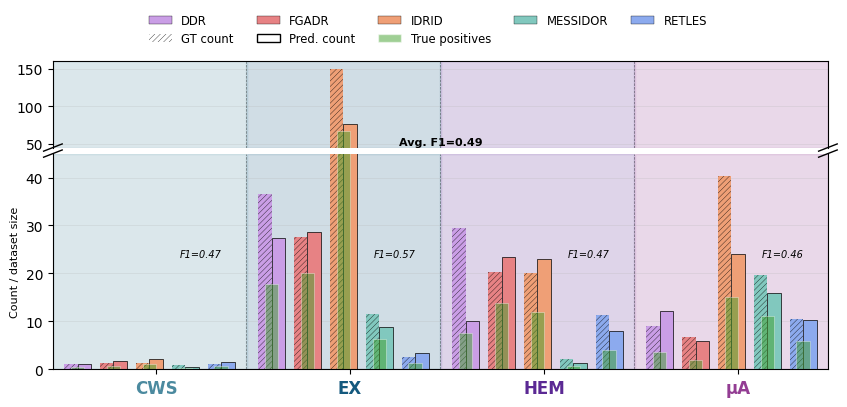

In [24]:
all_pickles = sorted(Path("Results").glob("fundus_*_detection.pkl"))
# --- Global lesion order (mean F1 across all models) ---
all_dfs = {p.stem: pd.read_pickle(p) for p in all_pickles}
for model_name, df in all_dfs.items():
    df["Model"] = (
        str(model_name)
        .replace("fundus_", "")
        .replace("_detection", "")
        .replace("_", " ")
    )
combined = pd.concat(all_dfs.values(), ignore_index=True)

fig = comparative_detection_plot(
    combined,
    n_cols=1,
    # model_choices=["CONVNEXT UNET", "SEGFORMER", "UNET", "ensemble best"],
    model_choices=["ensemble best"],
    legend_yloc=1.025,
    ax_width=10,
    hatch="//////",
    tp_width_factor=1.0,
    include_titles=False,
)
fig.savefig(
    ROOT_FIGURES / "LesionDetection_comparative_plot.png", dpi=300, bbox_inches="tight"
)

/home/clement/Documents/Projets/MultiStyleSeg/src/multistyleseg/charts/detection_plot.py:267: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["Model"] = pd.Categorical(


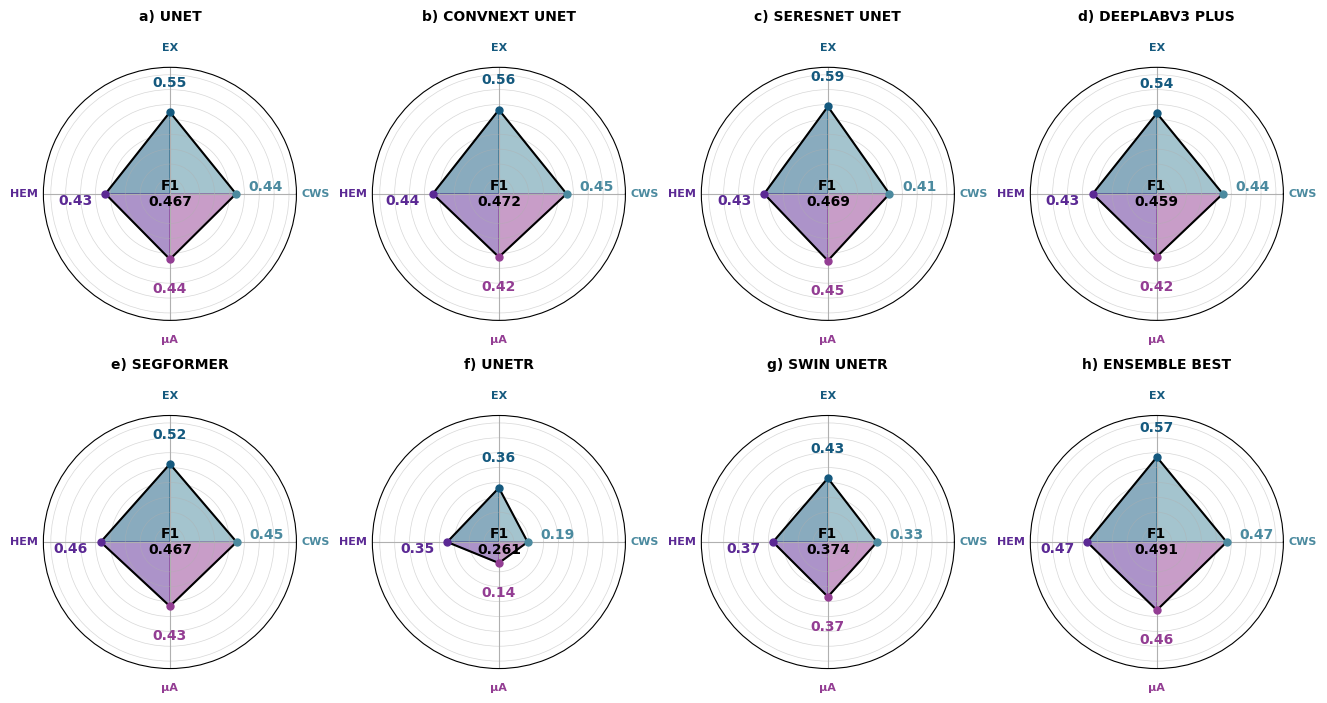

In [26]:
fig = comparative_detection_radar_plot(
    combined,
    per="lesion",
    n_cols=4,
    metric_name="F1",
    model_choices=[
        "UNET",
        "CONVNEXT UNET",
        "SERESNET UNET",
        "DEEPLABV3 PLUS",
        "SEGFORMER",
        "UNETR",
        "SWIN UNETR",
        "ensemble best",
    ],
    ylim=(0, 0.85),
)
fig.savefig(
    ROOT_FIGURES / "LesionDetection_radar_plot.png",
    dpi=300,
    bbox_inches="tight",
)

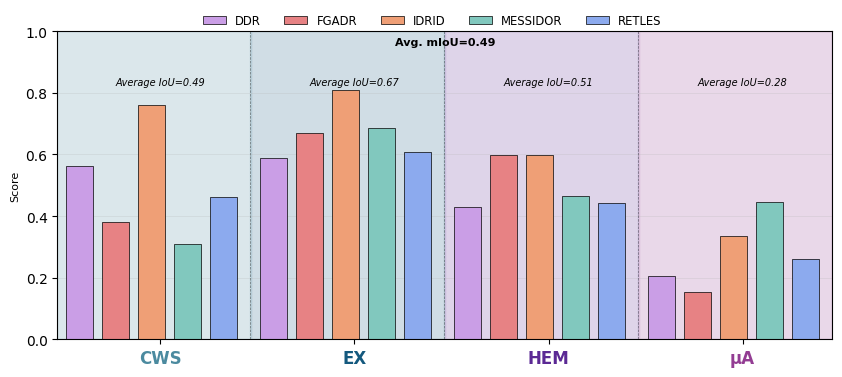

In [28]:
all_pickles = sorted(Path("Results").glob("fundus_*_pixel.pkl"))

# --- Global lesion order (mean IoU across all models, exclude MEAN column) ---
all_dfs = {p.stem: pd.read_pickle(p) for p in all_pickles}
for model_name, df in all_dfs.items():
    df["Model"] = (
        str(model_name).replace("fundus_", "").replace("_pixel", "").replace("_", " ")
    )
combined = pd.concat(all_dfs.values(), ignore_index=False)

comparative_segmentation_plot(
    combined,
    n_cols=1,
    metrics=["IoU"],
    metrics_hatches=[""],
    model_choices=["ensemble best"],
    legend_yloc=0.95,
    ax_width=10,
    include_titles=False,
)
plt.savefig(
    ROOT_FIGURES / "LesionSegmentation_comparative_plot.png",
    dpi=300,
    bbox_inches="tight",
)

/home/clement/Documents/Projets/MultiStyleSeg/src/multistyleseg/charts/segmentation_plot.py:194: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["Model"] = pd.Categorical(


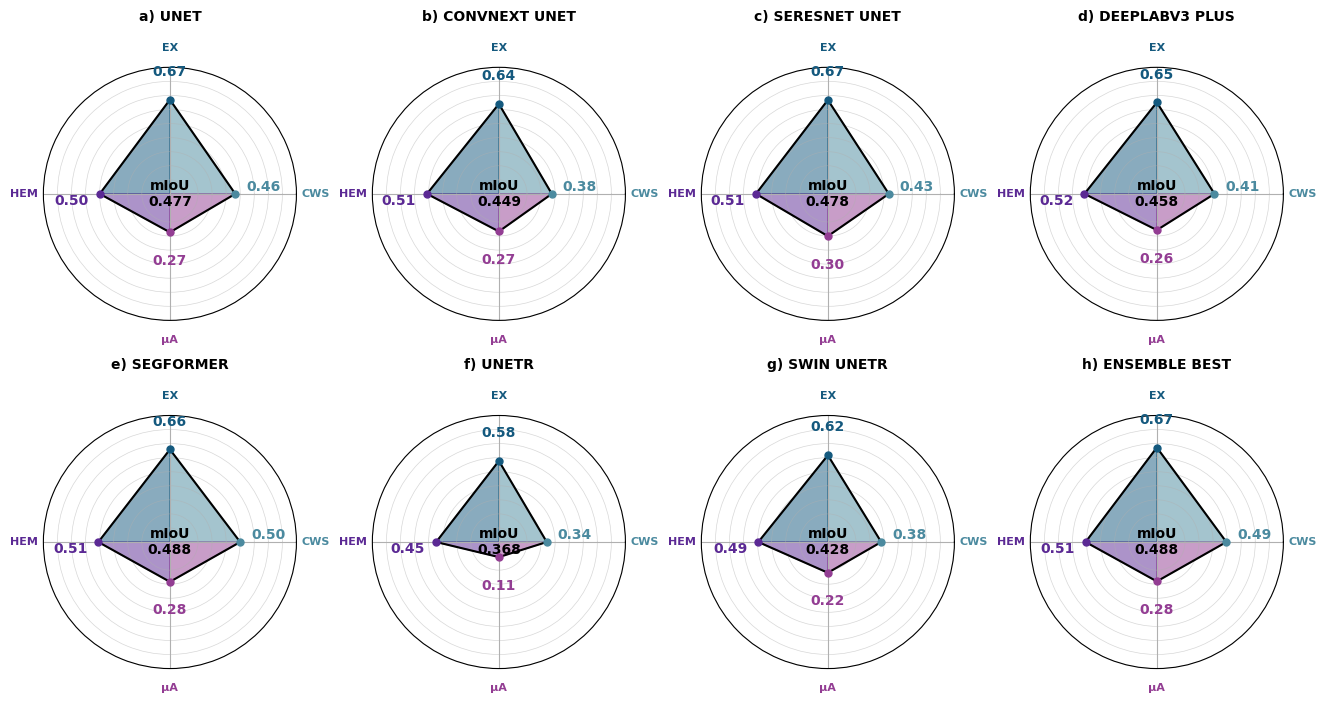

In [34]:
fig = comparative_segmentation_radar_plot(
    combined,
    per="lesion",
    n_cols=4,
    metric_name="mIoU",
    model_choices=[
        "UNET",
        "CONVNEXT UNET",
        "SERESNET UNET",
        "DEEPLABV3 PLUS",
        "SEGFORMER",
        "UNETR",
        "SWIN UNETR",
        "ensemble best",
    ],
    ylim=(0, 0.9),
)
fig.savefig(
    ROOT_FIGURES / "LesionSegmentation_radar_plot.png",
    dpi=300,
    bbox_inches="tight",
)